In [1]:
!pip install textblob

  Obtaining dependency information for textblob from https://files.pythonhosted.org/packages/1e/d6/40aa5aead775582ea0cf35870e5a3f16fab4b967f1ad2debe675f673f923/textblob-0.19.0-py3-none-any.whl.metadata
  Obtaining dependency information for nltk>=3.9 from https://files.pythonhosted.org/packages/c2/7e/9af5a710a1236e4772de8dfcc6af942a561327bb9f42b5b4a24d0cf100fd/nltk-3.9.3-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
    --------------------------------------- 10.2/624.3 kB ? eta -:--:--
   - ------------------------------------- 30.7/624.3 kB 435.7 kB/s eta 0:00:02
   -- ------------------------------------ 41.0/624.3 kB 388.9 kB/s eta 0:00:02
   ----- --------------------------------- 92.2/624.3 kB 655.4 kB/s eta 0:00:01
   ------- ------------------------------ 122.9/624.3 kB 552.2 kB/s eta 0:00:01
   --------------------- ------------------ 337.9/624.3 kB 1.2 MB/s eta 0:00:01
   ------------------------------ --------- 481.3/624.3 k

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

In [3]:
df = pd.read_csv("C:/Users/varsh/Downloads/twitter_training.csv/twitter_training.csv")   
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [4]:
df.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [8]:
df.columns = ['ID', 'Game', 'Sentiment', 'Tweet']

In [9]:
df.head()

,ID,Game,Sentiment,Tweet
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [10]:
df['Tweet'] = df['Tweet'].astype(str)

In [11]:
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['Sentiment_Score'] = df['Tweet'].apply(get_sentiment)

In [12]:
def categorize(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['Predicted_Sentiment'] = df['Sentiment_Score'].apply(categorize)

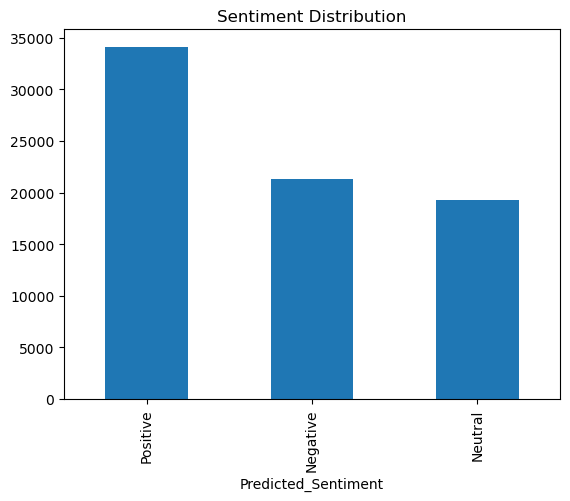

In [13]:
df['Predicted_Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

In [14]:
pd.crosstab(df['Sentiment'], df['Predicted_Sentiment'])

Predicted_Sentiment,Negative,Neutral,Positive
Sentiment,,,
Irrelevant,3249,3474,6267
Negative,10639,5903,6000
Neutral,4428,5581,8309
Positive,3036,4289,13506


# Key Insights

- Majority of posts are Positive.
- Negative posts indicate complaints or dissatisfaction.
- Neutral posts are mainly informational.
- Sentiment analysis helps understand public opinion.